# 03 - Exploratory Data Analysis

## Objective

The objective of this notebook is to explore the cleaned dataset and identify important patterns, distributions, relationships correlations, and potential outliers that may influence student dropout prediction.

The findings from this analysis will be used to guide feature engineering and model development.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

## Load Cleaned Dataset

In [2]:
df = pd.read_csv("../data/processed/student_dropout_cleaned.csv")

df.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,24.4,Male,29740.5,Yes,4.00,82.2,2,38.6,No,No,5.5,1.78,1.77,1.77,Year 1,CS,High School,1
4,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (10000, 18)


## Dataset Overview

The cleaned dataset was inspected to understand the data types, statistical characteristics, and overall structure of the features.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    10000 non-null  float64
 1   Gender                 10000 non-null  object 
 2   Family_Income          10000 non-null  float64
 3   Internet_Access        10000 non-null  object 
 4   Study_Hours_per_Day    10000 non-null  float64
 5   Attendance_Rate        10000 non-null  float64
 6   Assignment_Delay_Days  10000 non-null  int64  
 7   Travel_Time_Minutes    10000 non-null  float64
 8   Part_Time_Job          10000 non-null  object 
 9   Scholarship            10000 non-null  object 
 10  Stress_Index           10000 non-null  float64
 11  GPA                    10000 non-null  float64
 12  Semester_GPA           10000 non-null  float64
 13  CGPA                   10000 non-null  float64
 14  Semester               10000 non-null  object 
 15  Dep

In [5]:
df.describe()

,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,21.02606,37945.410100,4.013862,81.73683,1.799700,30.17926,5.506790,2.308440,2.300057,2.298761,0.23540
std,2.13981,20065.697032,1.262649,8.22093,1.344307,11.91887,1.721232,1.061717,1.074407,1.072555,0.42427
min,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,19.50000,25000.000000,3.210000,76.40000,1.000000,21.90000,4.400000,1.550000,1.520000,1.520000,0.00000
50%,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,22.50000,43361.750000,4.810000,87.30000,3.000000,38.40000,6.600000,3.120000,3.150000,3.150000,0.00000
max,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [6]:
df.describe(include="object")

,Gender,Internet_Access,Part_Time_Job,Scholarship,Semester,Department,Parental_Education
count,10000,10000,10000,10000,10000,10000,10000
unique,2,2,2,2,4,5,4
top,Female,Yes,No,No,Year 4,Science,Bachelor
freq,5011,8769,5996,6489,2536,2061,4460


## Target Variable Distribution

The distribution of the `Dropout` target variable was analyzed to understand the proportion of students who dropped out compared with those who did not.

The target distribution also indicates whether class imbalance should be considered during model development.

In [7]:
df["Dropout"].value_counts()

Dropout
0    7646
1    2354
Name: count, dtype: int64

In [8]:
df["Dropout"].value_counts(normalize=True) * 100

Dropout
0    76.46
1    23.54
Name: proportion, dtype: float64

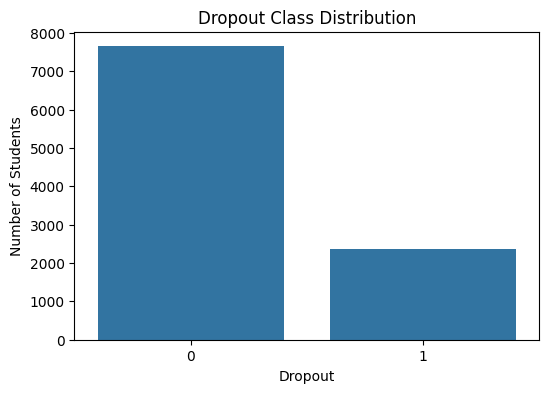

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Dropout")

plt.title("Dropout Class Distribution")
plt.xlabel("Dropout")
plt.ylabel("Number of Students")
plt.show()

## Visualization Utilities

The following reusable plotting function is used to display multiple charts in a grid layout, making the EDA visualizations more compact and easier to compare.

In [10]:
def plot_grid(columns, plot_func, figsize=(18, 5), cols_per_row=3):
    
    rows = math.ceil(len(columns) / cols_per_row)
    
    fig, axes = plt.subplots(
        rows,
        cols_per_row,
        figsize=(figsize[0], figsize[1] * rows)
    )
    
    axes = np.array(axes).flatten()
    
    for i, col in enumerate(columns):
        plot_func(col, axes[i])
    
    # Remove empty plots
    for i in range(len(columns), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

## Numerical Feature Analysis

In [11]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

numerical_columns

Index(['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate',
       'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA',
       'Semester_GPA', 'CGPA', 'Dropout'],
      dtype='object')

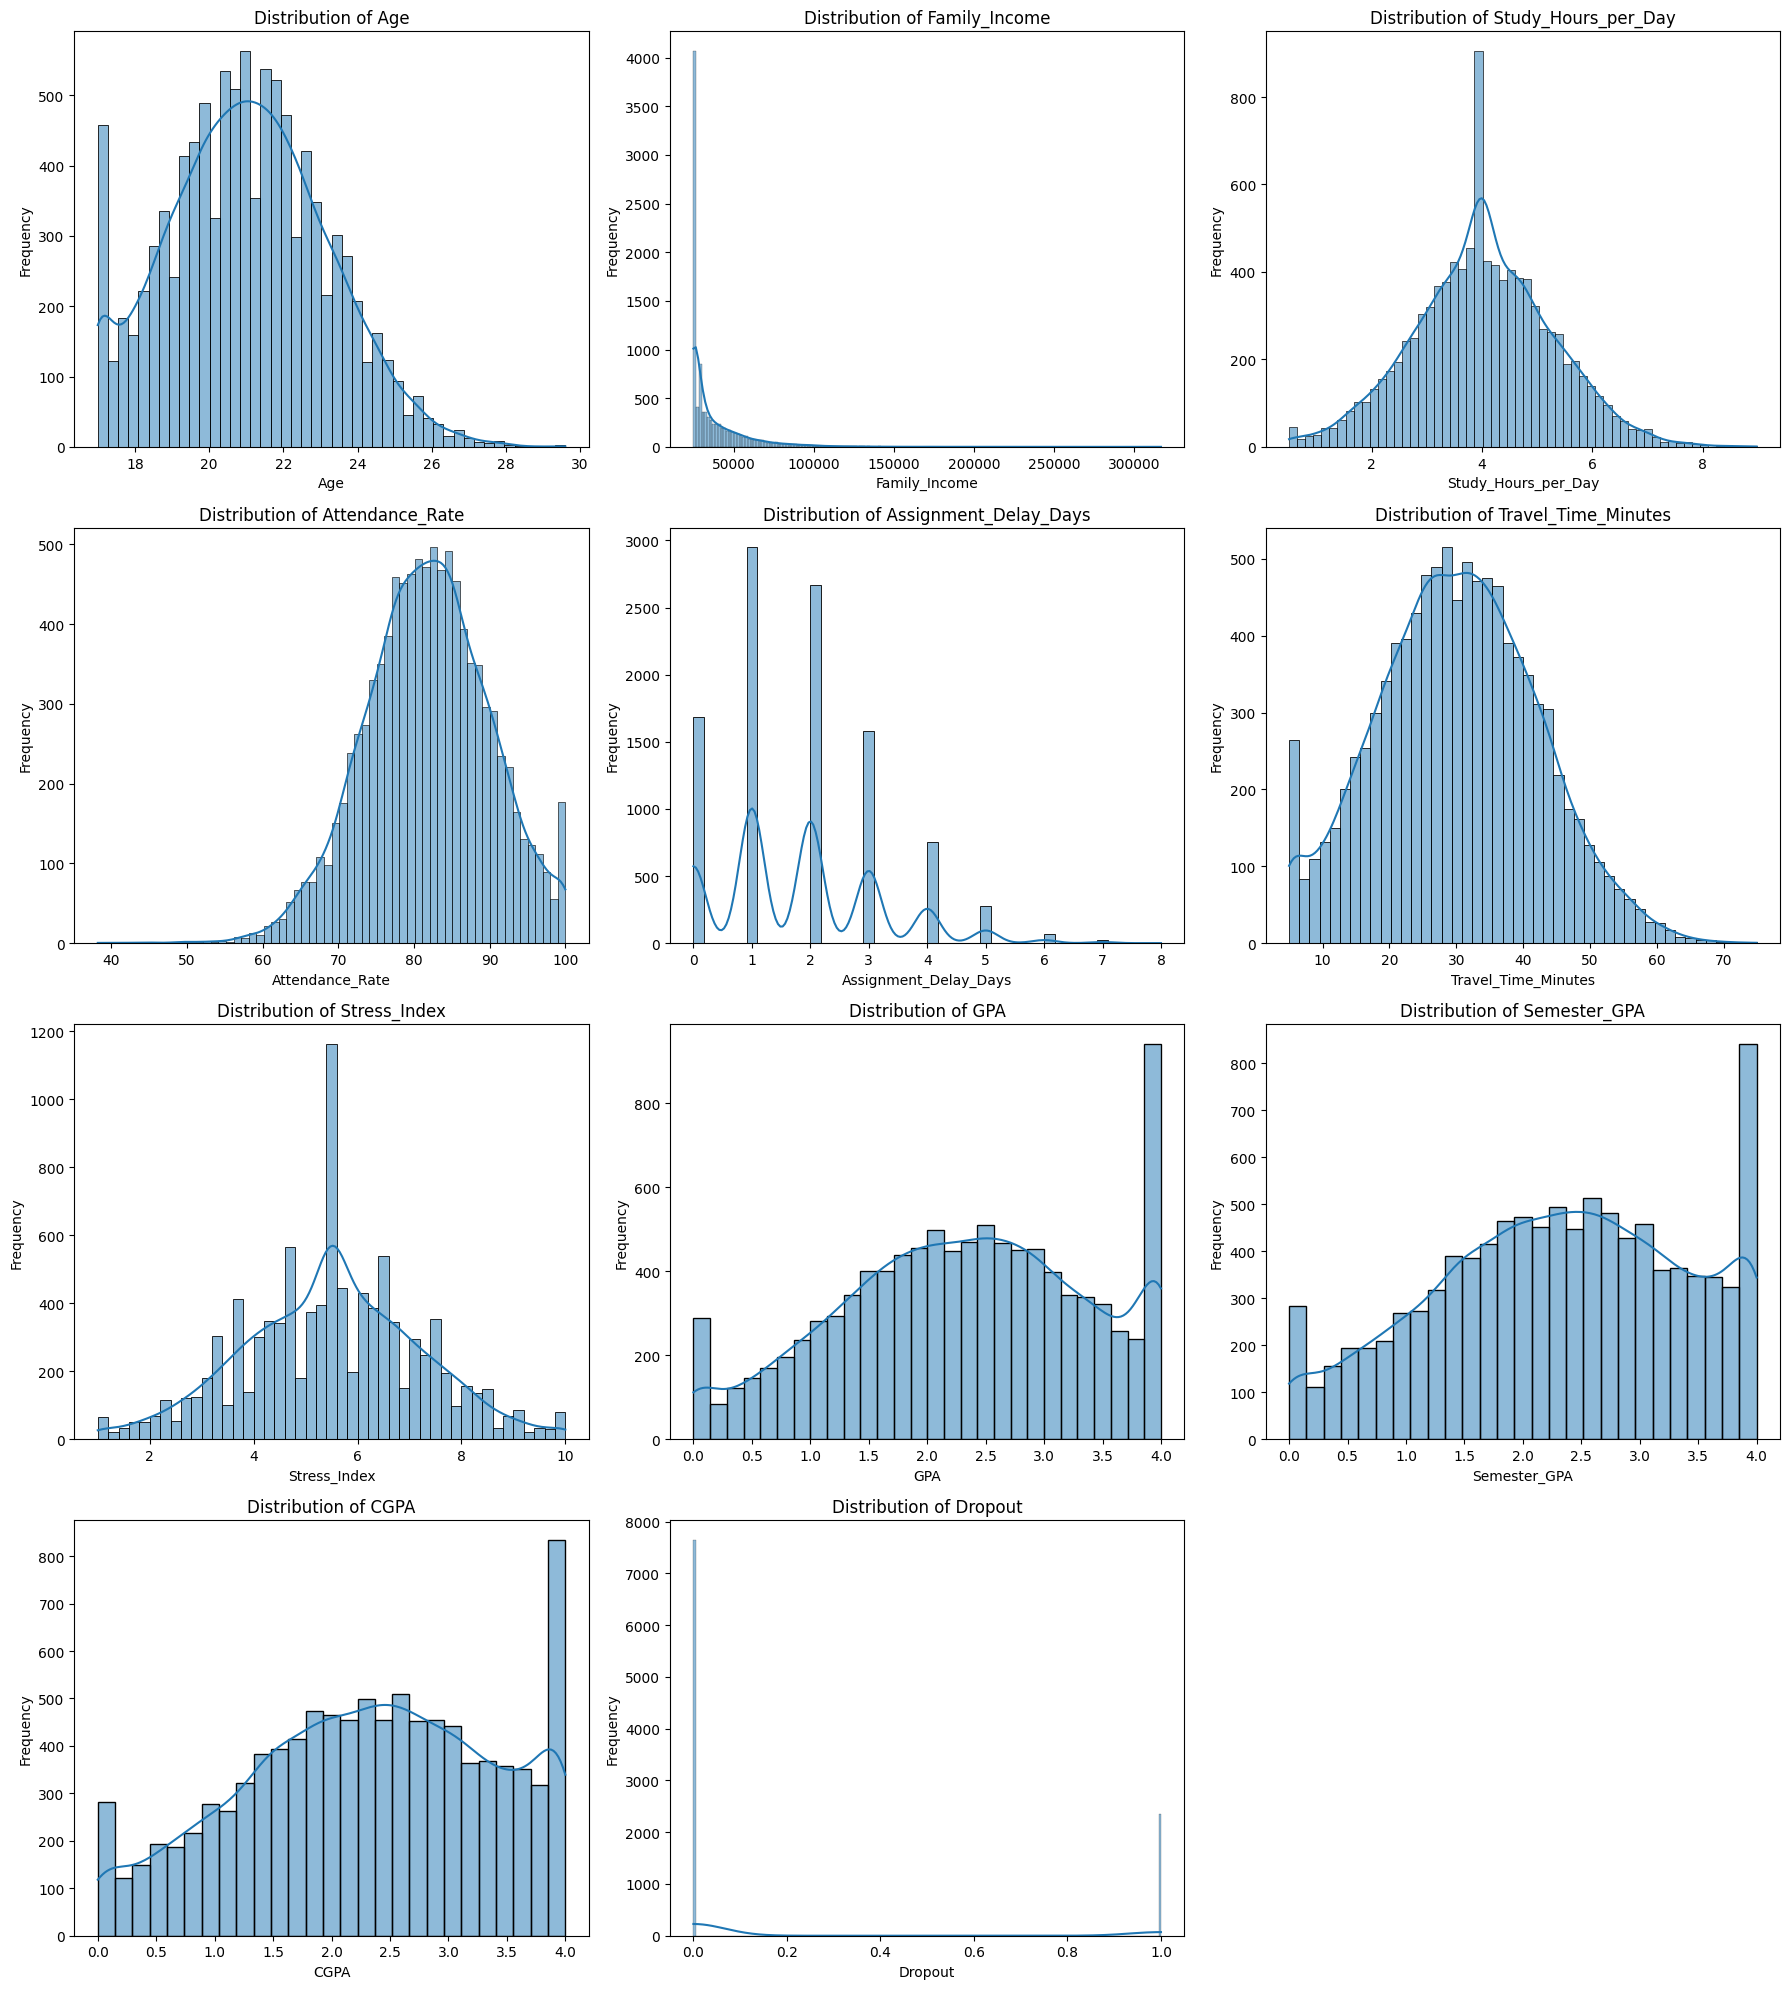

In [12]:
def histogram(col, ax):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plot_grid(numerical_columns, histogram)

## Categorical Feature Analysis

In [13]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

categorical_columns

Index(['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester',
       'Department', 'Parental_Education'],
      dtype='object')

In [14]:
for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


Gender
Gender
Female    5011
Male      4989
Name: count, dtype: int64

Internet_Access
Internet_Access
Yes    8769
No     1231
Name: count, dtype: int64

Part_Time_Job
Part_Time_Job
No     5996
Yes    4004
Name: count, dtype: int64

Scholarship
Scholarship
No     6489
Yes    3511
Name: count, dtype: int64

Semester
Semester
Year 4    2536
Year 3    2521
Year 2    2488
Year 1    2455
Name: count, dtype: int64

Department
Department
Science        2061
Arts           2026
Business       2002
CS             1974
Engineering    1937
Name: count, dtype: int64

Parental_Education
Parental_Education
Bachelor       4460
High School    3072
Master         2003
PhD             465
Name: count, dtype: int64


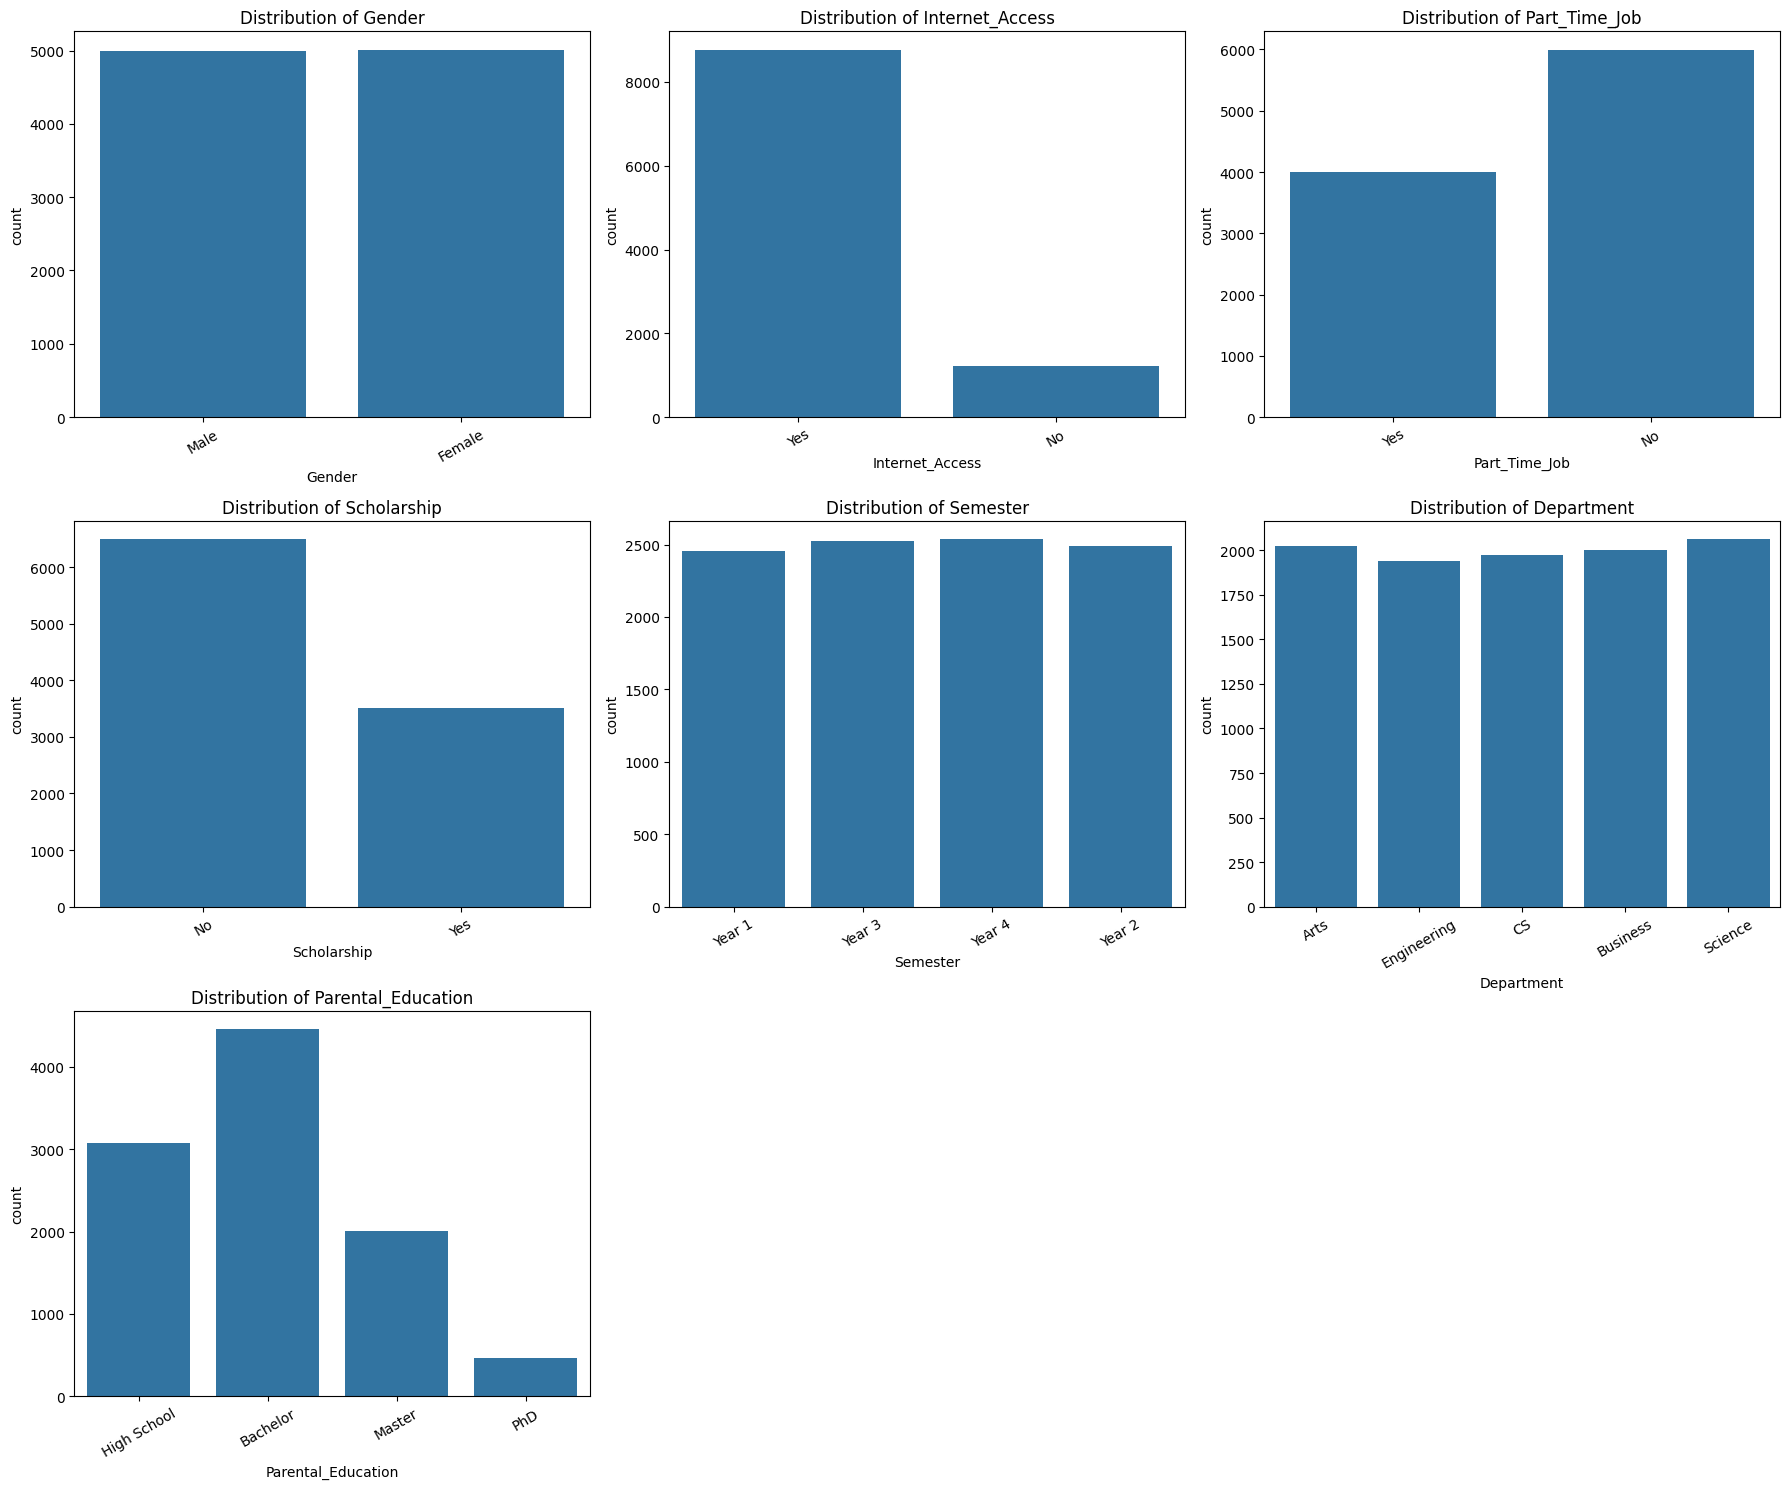

In [15]:
def countplot(col, ax):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.tick_params(axis="x", rotation=30)

plot_grid(categorical_columns, countplot)

## Correlation Analysis

A correlation matrix was used to identify relationships between numerical features.

Strong correlations between features were examined to identify potential redundancy and multicollinearity that may need to be considered during feature engineering.

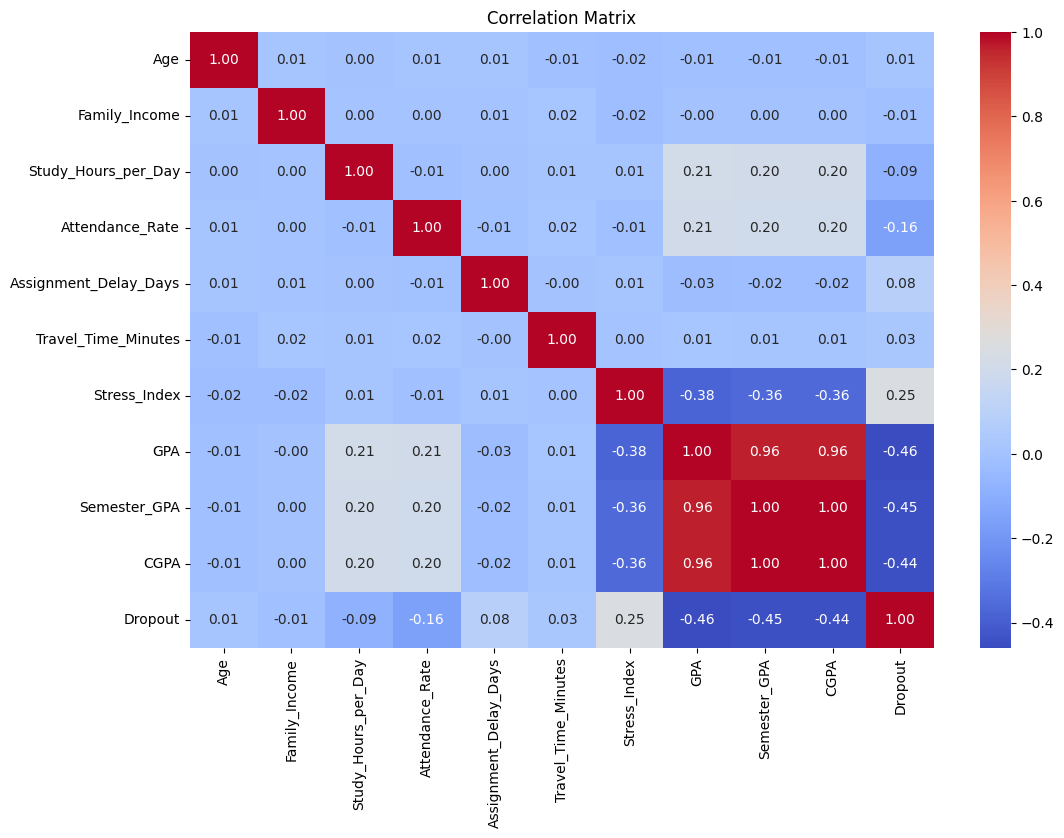

In [16]:
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

## Outlier Analysis

Boxplots were used to identify potential outliers in numerical features.

Particular attention was given to `Family_Income` because the initial data analysis indicated a highly right-skewed distribution.

Potential outliers will be considered during feature engineering and model development.

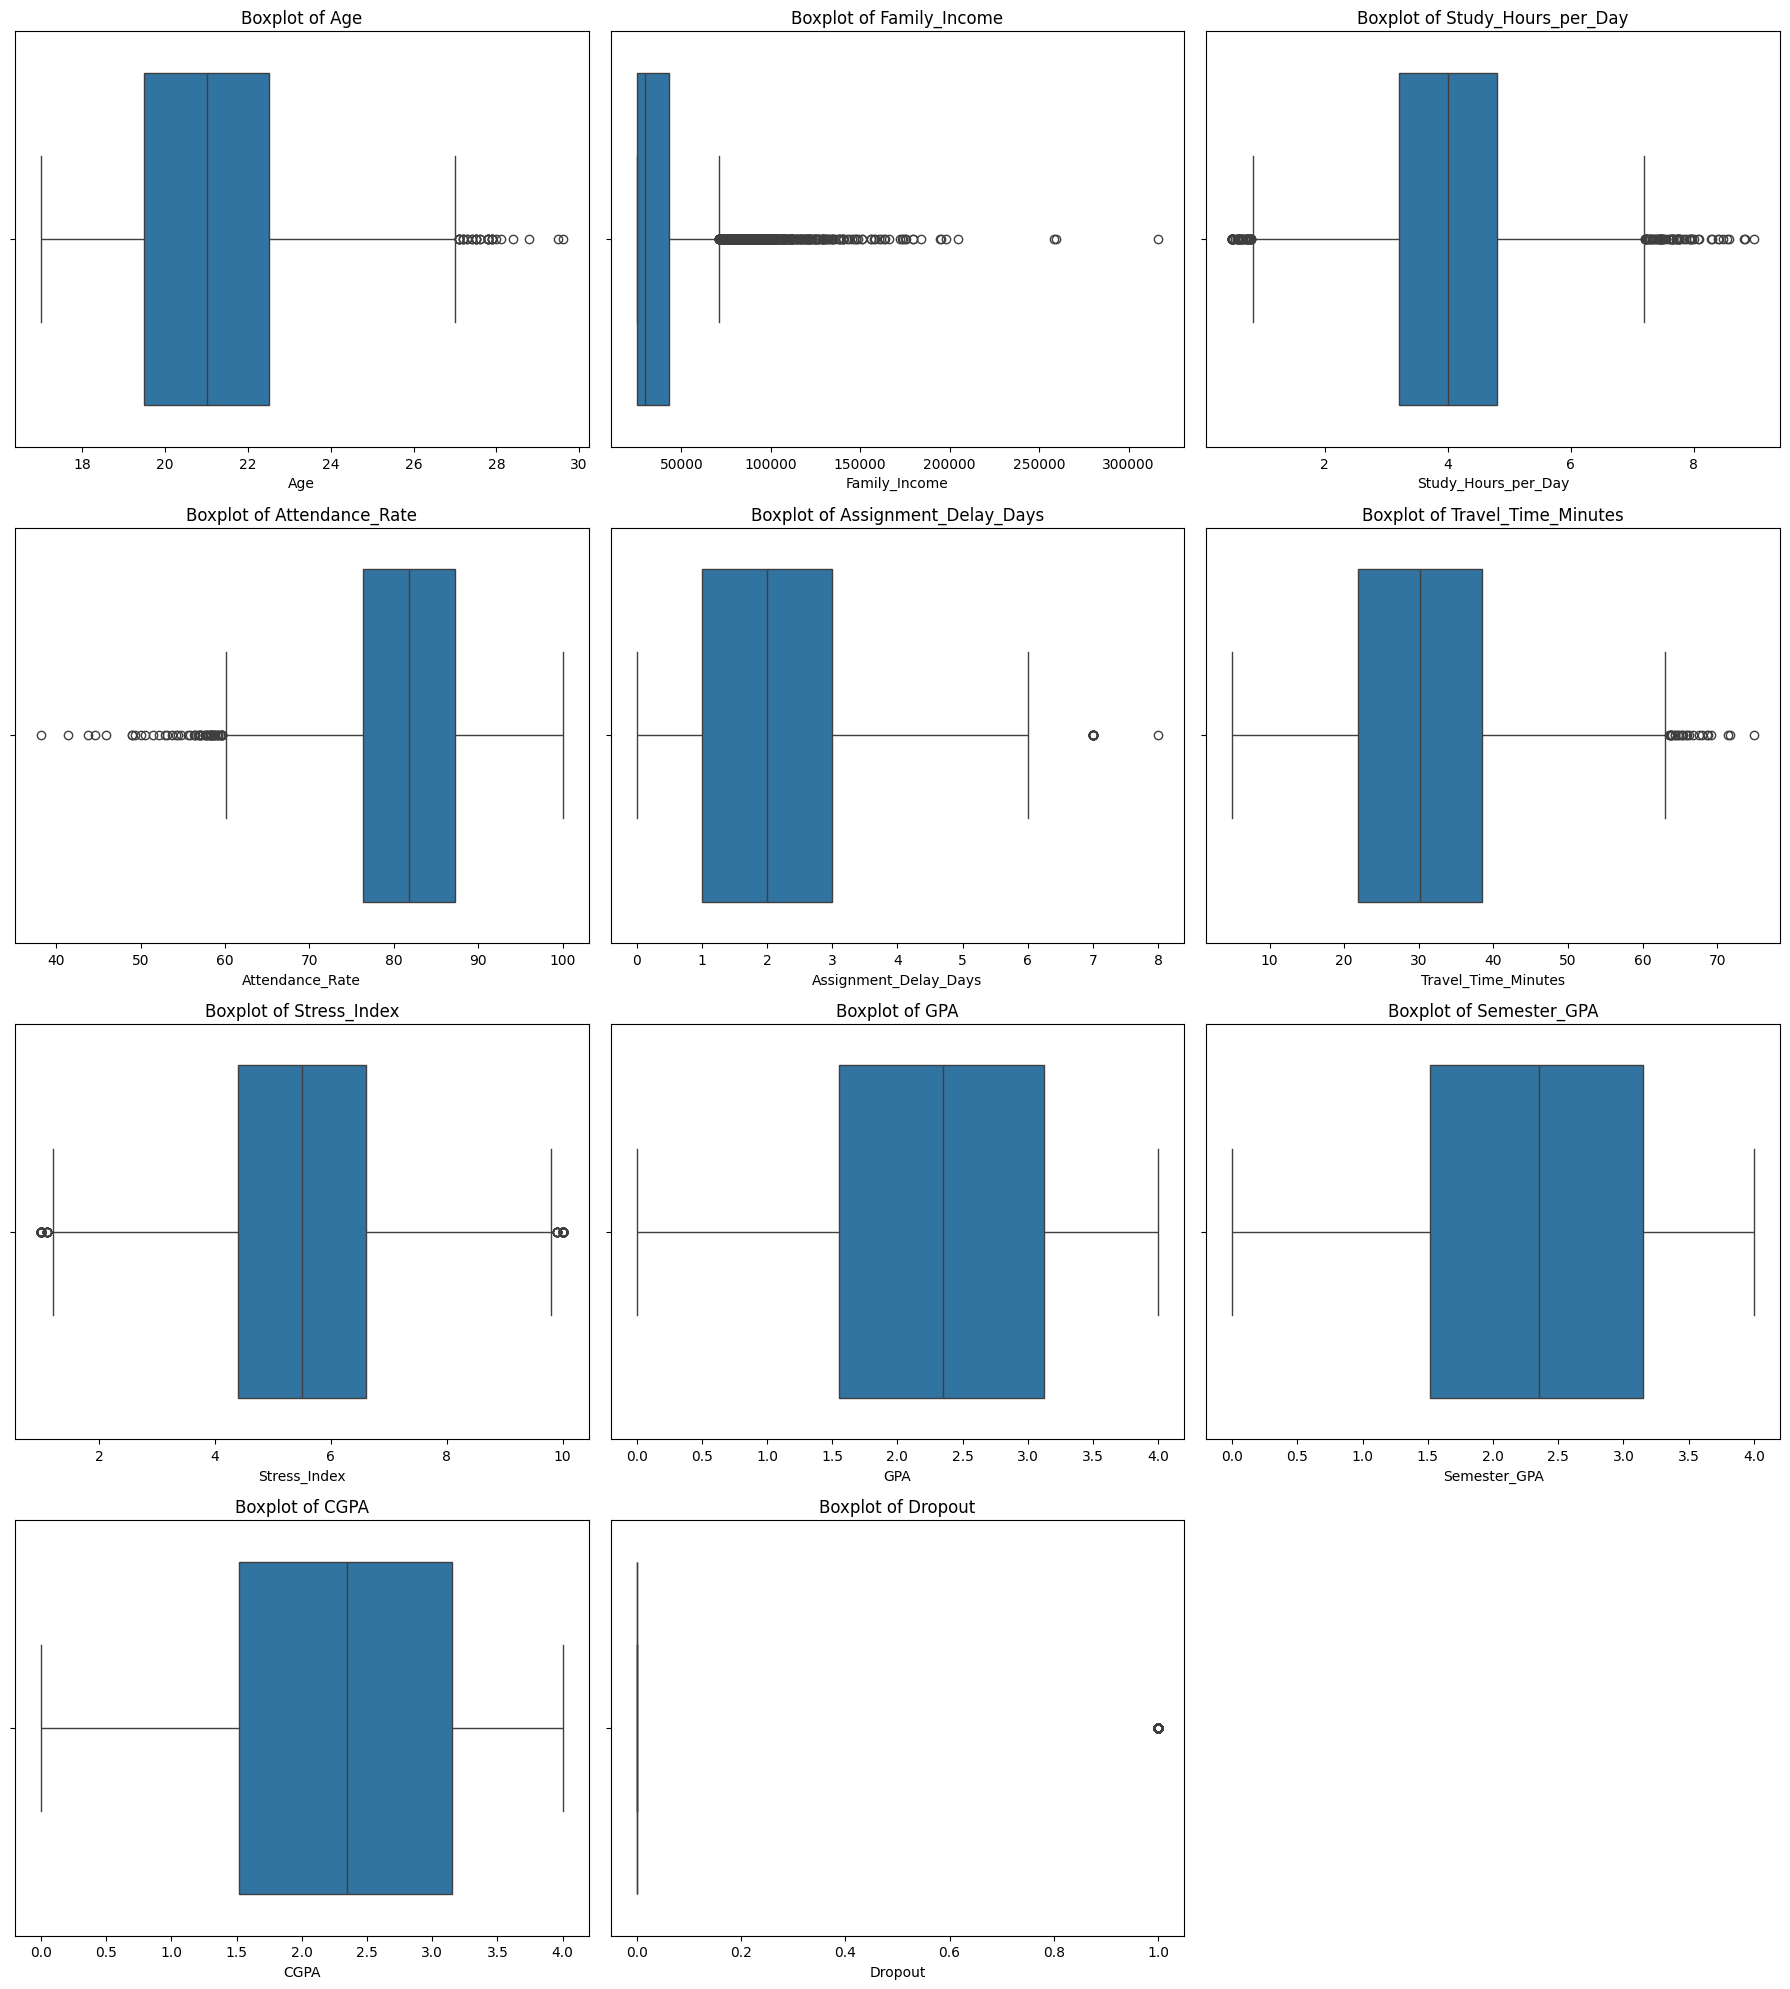

In [17]:
def boxplot(col, ax):
    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(f"Boxplot of {col}")

plot_grid(numerical_columns, boxplot)

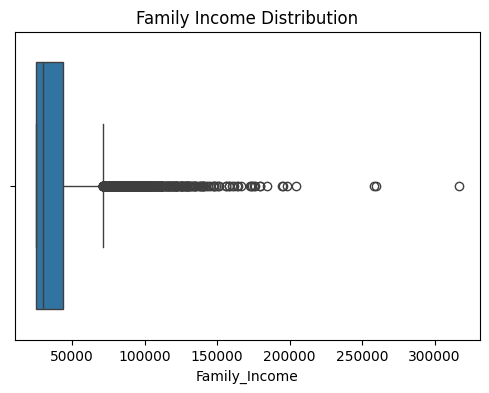

In [18]:
plt.figure(figsize=(6, 4))

sns.boxplot(data=df, x="Family_Income")

plt.title("Family Income Distribution")
plt.show()

## Feature vs Target Analysis

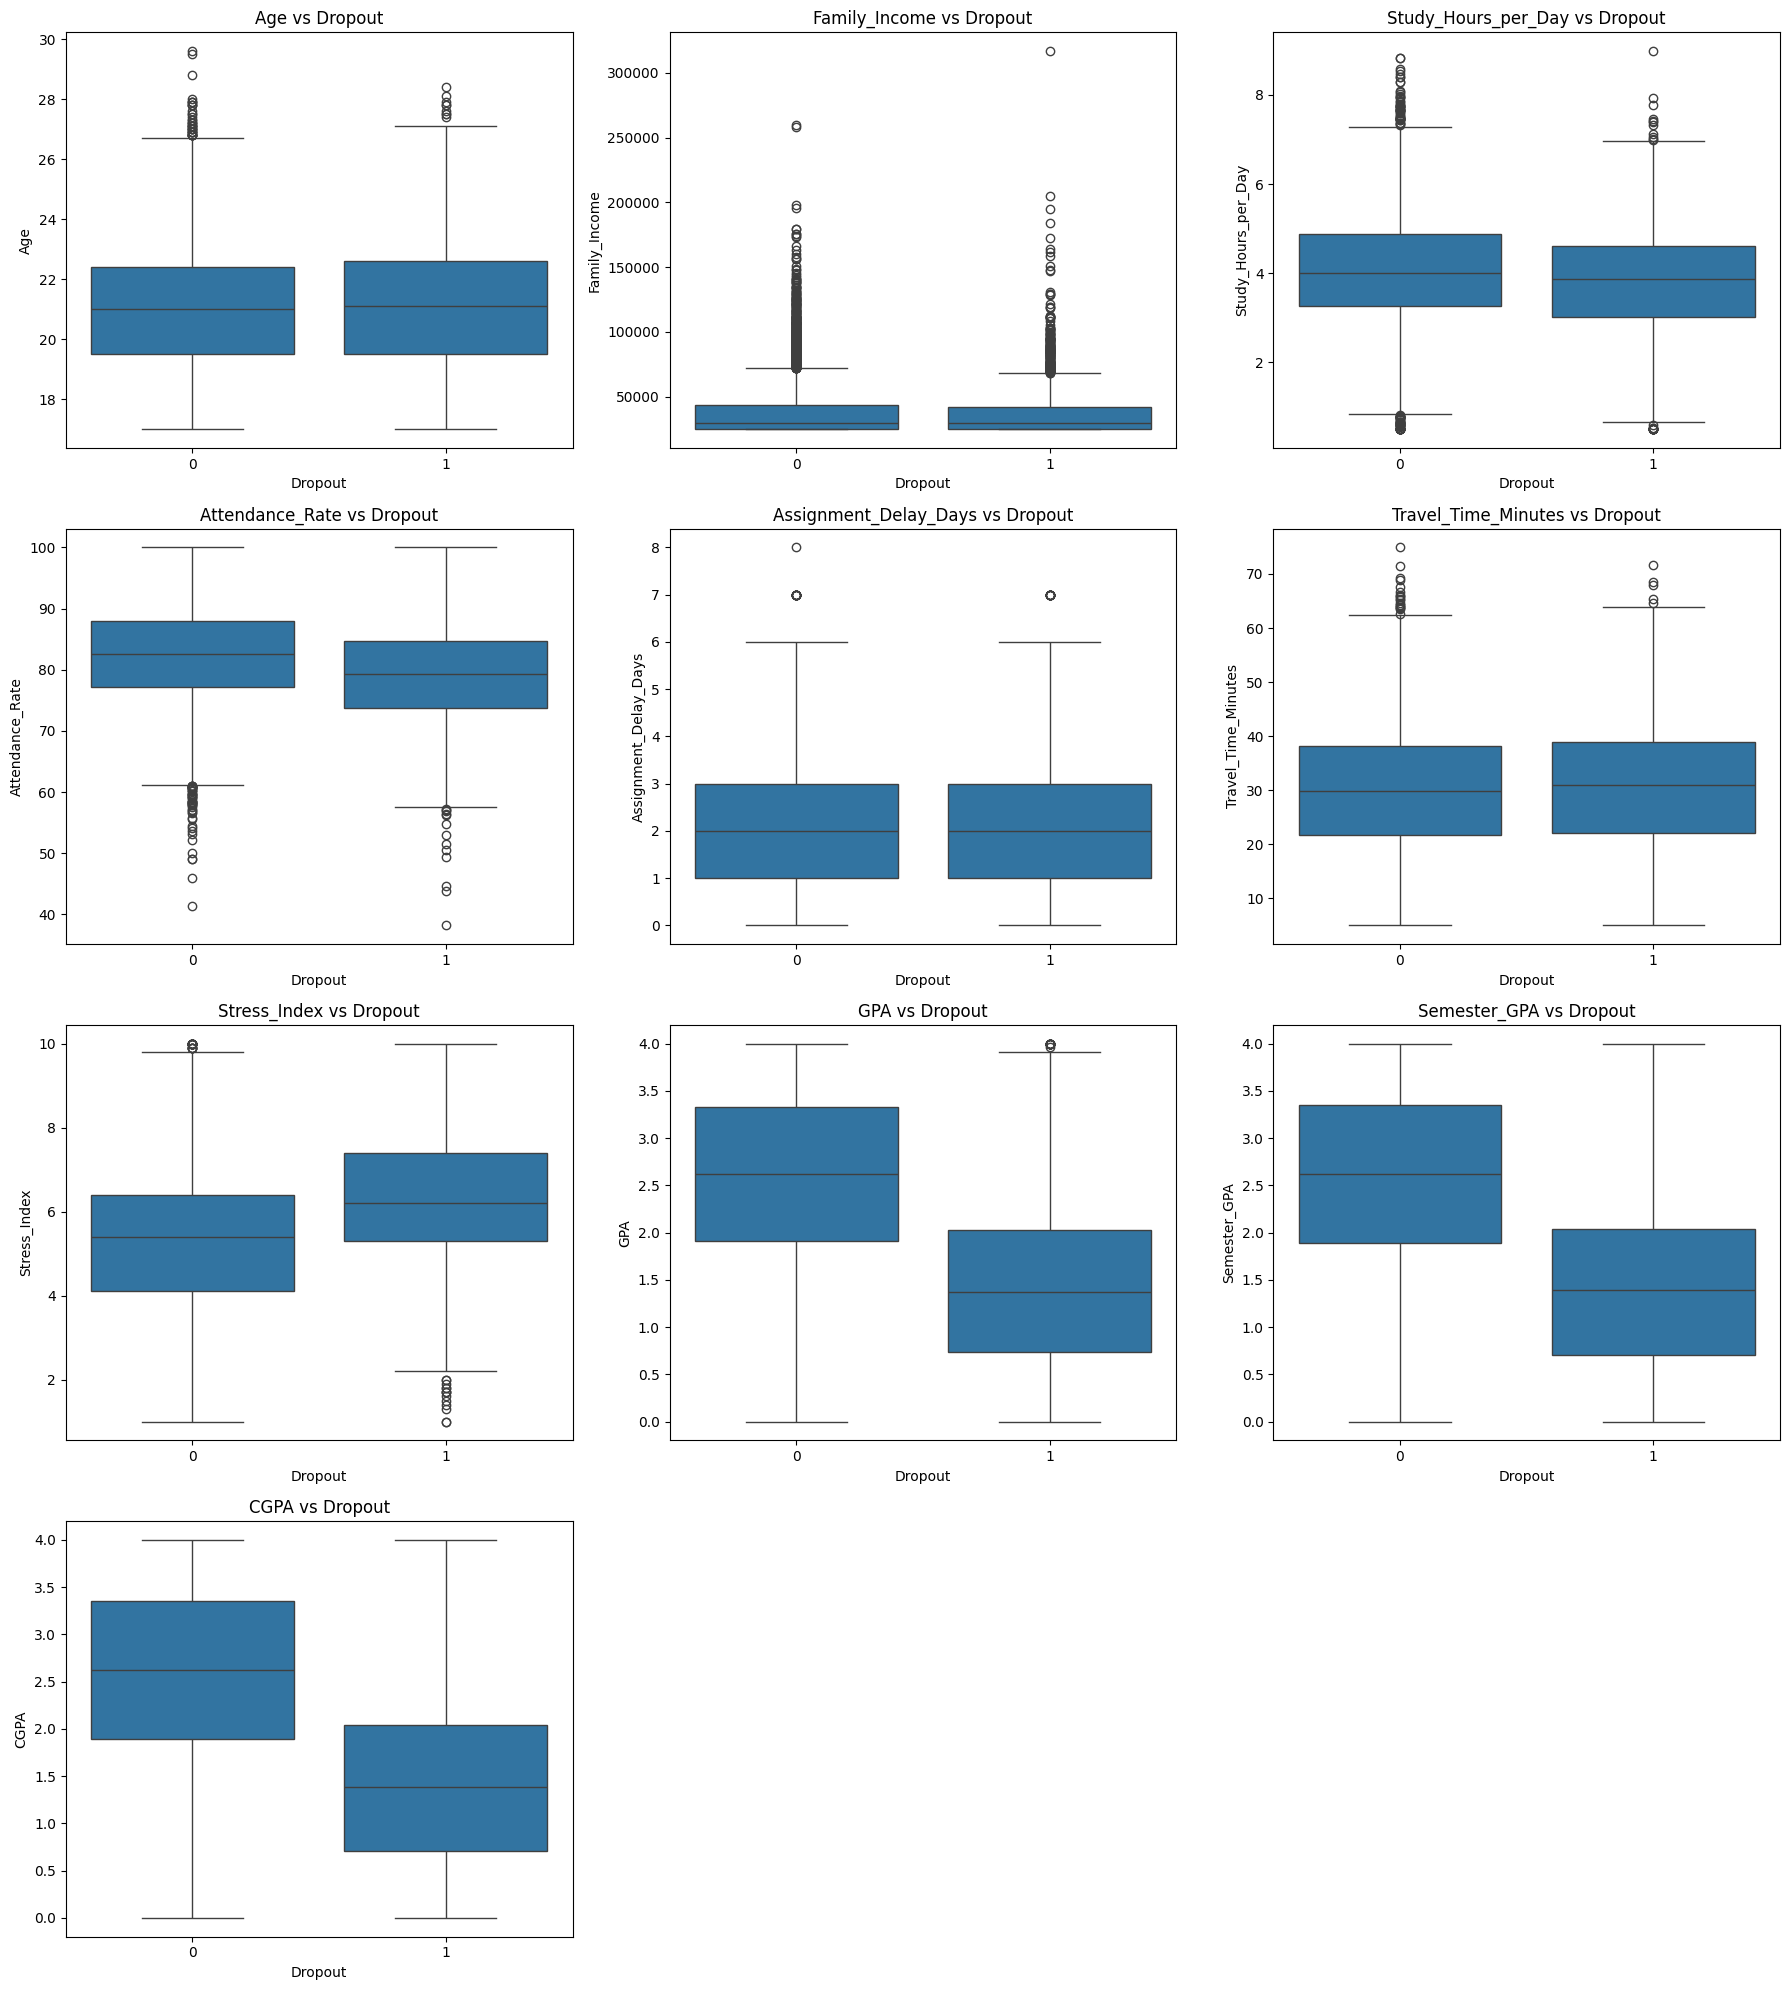

In [19]:
numerical_features = numerical_columns[numerical_columns != "Dropout"]

def numerical_vs_dropout(col, ax):
    sns.boxplot(data=df, x="Dropout", y=col, ax=ax)
    ax.set_title(f"{col} vs Dropout")

plot_grid(numerical_features, numerical_vs_dropout)

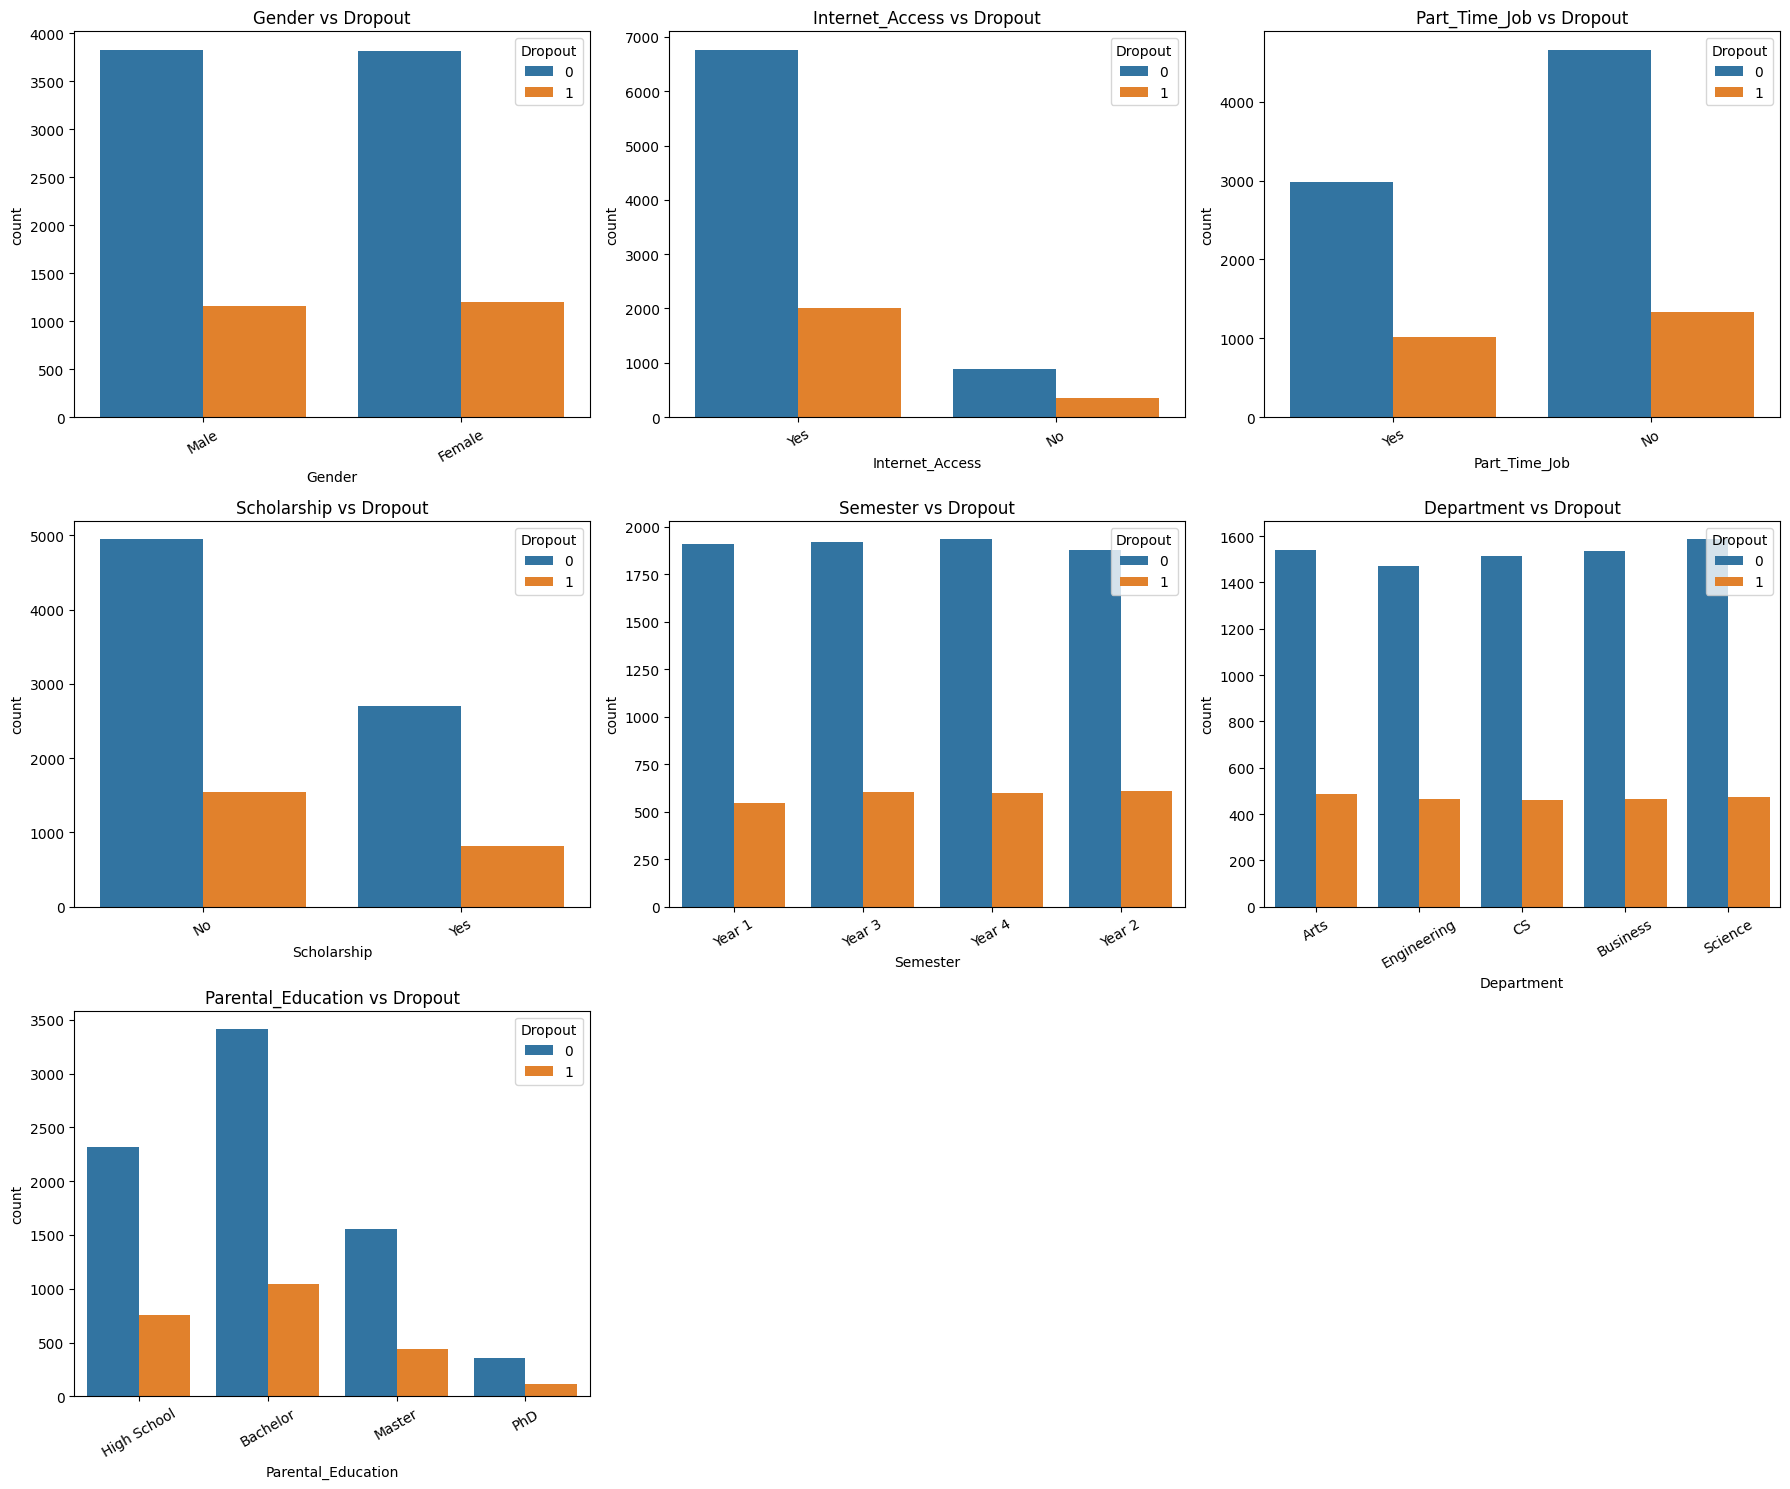

In [20]:
categorical_features = categorical_columns[categorical_columns != "Dropout"]

def categorical_vs_dropout(col, ax):
    sns.countplot(data=df, x=col, hue="Dropout", ax=ax)
    ax.set_title(f"{col} vs Dropout")
    ax.tick_params(axis="x", rotation=30)

plot_grid(categorical_features, categorical_vs_dropout)

## EDA Summary

The exploratory analysis provided the following key findings:

- The target variable `Dropout` shows a class imbalance between dropout and non-dropout students.
- Numerical features have different distributions and ranges.
- `Family_Income` shows a right-skewed distribution with potential outliers.
- Strong correlations were observed between selected academic features, particularly `GPA`, `Semester_GPA`, and `CGPA`.
- Differences in numerical features were observed across the dropout classes. For example, `GPA`, `Semester_GPA`, and `CGPA` tend to be lower for students who dropped out.
- Categorical features such as `Scholarship`, `Part_Time_Job`, and `Internet_Access` show different dropout patterns across their categories.
- The combined visualizations in the grid plots make it easier to compare multiple features and their relationship with the target variable at a glance.

These findings will be used to guide feature engineering, feature selection, and model development.